# ViT Testing Notebook

This notebook is the testing/inference version that matches your **Training.ipynb**.

It is designed for a test-data structure like:

```text
test/
├─ list/
│  ├─ test_age.txt
│  ├─ test_dis.txt
│  ├─ test_name.txt
│  ├─ train_age.txt
│  ├─ train_dis.txt
│  └─ train_name.txt
└─ test/
   ├─ 1.jpg
   └─ 2.jpg
```

Main assumptions:
- `test_name.txt` contains image filenames, one per line.
- `test_age.txt` contains the corresponding ages, one per line.
- Adult label is derived with `age >= adult_age`.
- `test_dis.txt` is optional metadata and is not required for adult/not-adult prediction.

If your actual text-file format is slightly different, adjust the parsing in **Cell 2**.


In [2]:

import csv
import json
from pathlib import Path
from typing import Dict, List, Optional

import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


try:
    import pandas as pd
except ImportError:
    pd = None


PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / 'test').exists()
    ),
    Path.cwd(),
)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def read_nonempty_lines(path: Path) -> List[str]:
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    with path.open('r', encoding='utf-8') as file:
        return [line.strip() for line in file if line.strip()]


def resolve_checkpoint_path(path_str: str) -> Path:
    path = Path(path_str)
    if path.is_absolute():
        return path
    return (PROJECT_ROOT / path).resolve()


def load_checkpoint_config(checkpoint_path: Path) -> Dict:
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    return checkpoint.get('config', {})


def safe_read_age_list(path: Path) -> Optional[List[int]]:
    if not path.exists():
        return None
    ages = []
    for line in read_nonempty_lines(path):
        try:
            ages.append(int(float(line)))
        except ValueError:
            raise ValueError(f'Invalid age value "{line}" in {path}')
    return ages


def safe_read_string_list(path: Path) -> Optional[List[str]]:
    if not path.exists():
        return None
    return read_nonempty_lines(path)


class ViTBinary(nn.Module):
    def __init__(self, pretrained: bool = False):
        super().__init__()
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        vit = models.vit_b_16(weights=weights)
        in_features = vit.heads.head.in_features
        vit.heads = nn.Identity()
        self.backbone = vit
        self.head = nn.Linear(in_features, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        return self.head(features).squeeze(1)


class FaceAdultTestDataset(Dataset):
    def __init__(self, records: List[Dict], tfm, adult_age: int = 21):
        self.records = records
        self.tfm = tfm
        self.adult_age = adult_age

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index: int):
        record = self.records[index]
        image = Image.open(record['image_path']).convert('RGB')
        image = self.tfm(image)

        age = record.get('age')
        label = None if age is None else float(age >= self.adult_age)

        return {
            'image': image,
            'name': record['name'],
            'age': age,
            'label': label,
            'dis': record.get('dis'),
            'image_path': str(record['image_path']),
        }


def collate_test_batch(batch):
    images = torch.stack([item['image'] for item in batch], dim=0)
    names = [item['name'] for item in batch]
    ages = [item['age'] for item in batch]
    labels = [item['label'] for item in batch]
    dis_list = [item['dis'] for item in batch]
    image_paths = [item['image_path'] for item in batch]

    label_tensor = None
    if all(label is not None for label in labels):
        label_tensor = torch.tensor(labels, dtype=torch.float32)

    return {
        'images': images,
        'names': names,
        'ages': ages,
        'labels': label_tensor,
        'dis_list': dis_list,
        'image_paths': image_paths,
    }


@torch.no_grad()
def run_inference(model, loader, device, threshold: float = 0.5, use_amp: bool = False):
    model.eval()
    rows = []

    tp = fp = tn = fn = 0
    total = 0

    for batch in loader:
        images = batch['images'].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, enabled=use_amp):
            logits = model(images)

        probs = torch.sigmoid(logits).detach().cpu()
        preds = (probs >= threshold).float()

        labels = batch['labels']
        if labels is not None:
            labels = labels.cpu()

        for i in range(len(batch['names'])):
            row = {
                'name': batch['names'][i],
                'image_path': batch['image_paths'][i],
                'age': batch['ages'][i],
                'dis': batch['dis_list'][i],
                'prob_adult': float(probs[i].item()),
                'pred_label': int(preds[i].item()),
                'pred_class': 'adult' if int(preds[i].item()) == 1 else 'not_adult',
            }

            if labels is not None:
                true_label = int(labels[i].item())
                row['true_label'] = true_label
                row['true_class'] = 'adult' if true_label == 1 else 'not_adult'

                total += 1
                if row['pred_label'] == 1 and true_label == 1:
                    tp += 1
                elif row['pred_label'] == 1 and true_label == 0:
                    fp += 1
                elif row['pred_label'] == 0 and true_label == 0:
                    tn += 1
                else:
                    fn += 1

            rows.append(row)

    metrics = None
    if total > 0:
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = (2 * precision * recall) / max(precision + recall, 1e-12)
        acc = (tp + tn) / max(total, 1)
        metrics = {
            'total': total,
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp,
            'tn': tn,
            'fp': fp,
            'fn': fn,
        }

    return rows, metrics


In [3]:

CONFIG = {
    'test_root': str(PROJECT_ROOT / 'test'),
    'list_dir': str(PROJECT_ROOT / 'test' / 'list'),
    'image_dir': str(PROJECT_ROOT / 'test' / 'test'),

    # Point this to the checkpoint you want to test.
    # Change to fine-tuned checkpoint if needed.
    'checkpoint_path': str(PROJECT_ROOT / 'Model' / 'ViT' / 'runs' / 'vit_adult_binary' / 'best_vit_finetuned.pt'),

    # Output directory for testing results
    'out_dir': str(PROJECT_ROOT / 'Model' / 'ViT' / 'runs' / 'vit_adult_binary' / 'test_results'),

    # Testing options
    'batch_size': 16,
    'num_workers': 0,
    'adult_age': 21,
    'threshold': None,   # None = try loading from checkpoint config
    'img_size': None,    # None = try loading from checkpoint config
    'use_amp': True,
}

checkpoint_path = resolve_checkpoint_path(CONFIG['checkpoint_path'])
if not checkpoint_path.exists():
    raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

ckpt_config = load_checkpoint_config(checkpoint_path)

if CONFIG['threshold'] is None:
    CONFIG['threshold'] = float(ckpt_config.get('threshold', 0.5))

if CONFIG['img_size'] is None:
    CONFIG['img_size'] = int(ckpt_config.get('img_size', 224))

if 'adult_age' in ckpt_config:
    CONFIG['adult_age'] = int(ckpt_config['adult_age'])

CONFIG


{'test_root': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\test',
 'list_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\test\\list',
 'image_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\test\\test',
 'checkpoint_path': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\Model\\ViT\\runs\\vit_adult_binary\\best_vit_finetuned.pt',
 'out_dir': 'D:\\JiShou\\D-Y2S3\\BMCS2074 - Artificial Intelligence\\Assignment\\AI_Assignment\\Model\\ViT\\runs\\vit_adult_binary\\test_results',
 'batch_size': 16,
 'num_workers': 0,
 'adult_age': 21,
 'threshold': 0.457286,
 'img_size': 224,
 'use_amp': True}

In [4]:

test_root = Path(CONFIG['test_root'])
list_dir = Path(CONFIG['list_dir'])
image_dir = Path(CONFIG['image_dir'])
out_dir = Path(CONFIG['out_dir'])
out_dir.mkdir(parents=True, exist_ok=True)

test_name_path = list_dir / 'test_name.txt'
test_age_path = list_dir / 'test_age.txt'
test_dis_path = list_dir / 'test_dis.txt'

names = read_nonempty_lines(test_name_path)
ages = safe_read_age_list(test_age_path)
dis_list = safe_read_string_list(test_dis_path)

if ages is not None and len(ages) != len(names):
    raise ValueError(f'Mismatch: {test_age_path.name} has {len(ages)} rows but {test_name_path.name} has {len(names)} rows')

if dis_list is not None and len(dis_list) != len(names):
    raise ValueError(f'Mismatch: {test_dis_path.name} has {len(dis_list)} rows but {test_name_path.name} has {len(names)} rows')

records = []
for idx, name in enumerate(names):
    image_path = image_dir / name
    if not image_path.exists():
        raise FileNotFoundError(f'Image listed in {test_name_path.name} not found: {image_path}')

    records.append({
        'name': name,
        'image_path': image_path,
        'age': None if ages is None else ages[idx],
        'dis': None if dis_list is None else dis_list[idx],
    })

test_tfm = transforms.Compose([
    transforms.Resize(int(CONFIG['img_size'] * 1.14)),
    transforms.CenterCrop(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = FaceAdultTestDataset(records, test_tfm, adult_age=CONFIG['adult_age'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_pin_memory = device.type == 'cuda'
use_amp = CONFIG['use_amp'] and device.type == 'cuda'

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=use_pin_memory,
    collate_fn=collate_test_batch,
)

model = ViTBinary(pretrained=False).to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f'Test root      : {test_root.resolve()}')
print(f'List dir       : {list_dir.resolve()}')
print(f'Image dir      : {image_dir.resolve()}')
print(f'Checkpoint     : {checkpoint_path}')
print(f'Num test images: {len(test_dataset)}')
print(f'Adult age      : {CONFIG["adult_age"]}')
print(f'Threshold      : {CONFIG["threshold"]:.6f}')
print(f'Device         : {device}')


Test root      : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\test
List dir       : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\test\list
Image dir      : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\test\test
Checkpoint     : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\ViT\runs\vit_adult_binary\best_vit_finetuned.pt
Num test images: 3945
Adult age      : 21
Threshold      : 0.457286
Device         : cuda


Predictions CSV : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\ViT\runs\vit_adult_binary\test_results\test_predictions.csv
Predictions JSON: D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\ViT\runs\vit_adult_binary\test_results\test_predictions.json
Metrics JSON    : D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\ViT\runs\vit_adult_binary\test_results\test_metrics.json

Test metrics:
  total: 3945
  accuracy: 0.842079
  precision: 0.926016
  recall: 0.752959
  f1: 0.830568
  tp: 1527
  tn: 1795
  fp: 122
  fn: 501

Confusion Matrix:


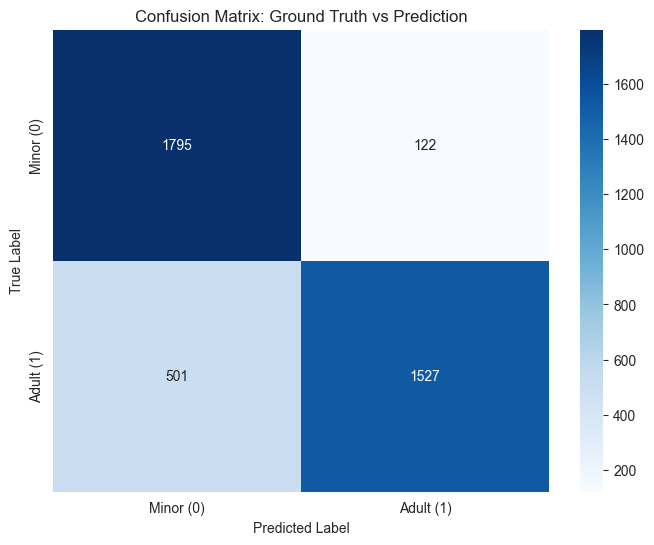

,name,image_path,age,dis,prob_adult,pred_label,pred_class,true_label,true_class
0,1.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,0.000002,0,not_adult,0,not_adult
1,2.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,0.000002,0,not_adult,0,not_adult
2,3.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,2,3.367549e-02 1.629141e-01 1.915395e-01 2.03727...,0.000013,0,not_adult,0,not_adult
3,4.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,0.000001,0,not_adult,0,not_adult
4,5.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,1,1.674574e-01 1.981500e-01 2.112185e-01 1.98150...,0.000038,0,not_adult,0,not_adult
...,...,...,...,...,...,...,...,...,...
3940,3941.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,5,1.108530e-03 4.384320e-03 1.350466e-02 3.23959...,0.005730,0,not_adult,0,not_adult
3941,3942.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,5,1.108530e-03 4.384320e-03 1.350466e-02 3.23959...,0.000142,0,not_adult,0,not_adult
3942,3943.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,7,3.345785e-05 2.181726e-04 1.107972e-03 4.38211...,0.001121,0,not_adult,0,not_adult
3943,3944.jpg,D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelli...,8,3.995938e-06 3.345758e-05 2.181708e-04 1.10796...,0.000126,0,not_adult,0,not_adult


In [5]:

rows, metrics = run_inference(
    model=model,
    loader=test_loader,
    device=device,
    threshold=CONFIG['threshold'],
    use_amp=use_amp,
)

pred_csv_path = out_dir / 'test_predictions.csv'
pred_json_path = out_dir / 'test_predictions.json'
metrics_json_path = out_dir / 'test_metrics.json'

with pred_csv_path.open('w', newline='', encoding='utf-8') as file:
    if rows:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

with pred_json_path.open('w', encoding='utf-8') as file:
    json.dump(rows, file, indent=2)

if metrics is not None:
    with metrics_json_path.open('w', encoding='utf-8') as file:
        json.dump(metrics, file, indent=2)

print(f'Predictions CSV : {pred_csv_path}')
print(f'Predictions JSON: {pred_json_path}')

if metrics is not None:
    print(f'Metrics JSON    : {metrics_json_path}')
    print('\nTest metrics:')
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f'  {key}: {value:.6f}')
        else:
            print(f'  {key}: {value}')
else:
    print('\nNo test labels detected, so only inference results were saved.')

if metrics is not None:
    print("\nConfusion Matrix:")

    tp = metrics['tp']
    tn = metrics['tn']
    fp = metrics['fp']
    fn = metrics['fn']

    cm = [
        [tn, fp],
        [fn, tp]
    ]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Minor (0)', 'Adult (1)'],
        yticklabels=['Minor (0)', 'Adult (1)'],
    )

    plt.title('Confusion Matrix: Ground Truth vs Prediction')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

if pd is not None:
    display(pd.DataFrame(rows))
else:
    rows[:10]
